<div style="border-bottom: 2px solid #e8a435; padding-bottom: 20px; margin-bottom: 30px;">
<div style="display: flex; align-items: center; gap: 16px;">
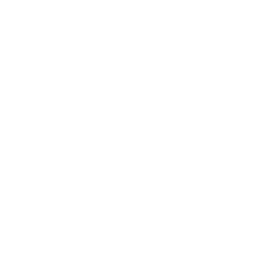
<div>
<h1 style="margin: 0; font-family: 'Inter', 'Helvetica Neue', sans-serif; font-weight: 700; color: #1a1a2e; font-size: 28px; letter-spacing: -0.5px;">Dokumentacja schematu adnotacji wariantów genomowych</h1>
<p style="margin: 4px 0 0 0; font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #6c6c8a; font-size: 14px;">Jenner Analytics Ltd &nbsp;|&nbsp; Bioinformatyka / Zarządzanie danymi genomiki klinicznej &nbsp;|&nbsp; Marzec 2026</p>
</div>
</div>
</div>

## Podsumowanie dla kierownictwa

Udokumentuj schemat zbiorów danych adnotacji wariantów typu VCF wykorzystywanych w potoku genomiki klinicznej. Użyj PROC CONTENTS do skatalogowania wszystkich pól adnotacji — współrzędnych genomowych, częstości alleli, przewidywanych efektów funkcjonalnych, klasyfikacji ClinVar oraz metryk jakości — aby zapewnić, że narzędzia interpretacji wariantów ACMG w dalszej części potoku otrzymają dane wejściowe o poprawnych typach i etykietach. Przed przekazaniem do potoku sprawdzana jest integralność schematu około 5 000 rekordów wariantów zawierających ponad 20 kolumn adnotacji.

## Źródła danych

| Źródło | Opis | Rekordy |
|--------|-------------|--------|
| VARIANT_ANNOTATIONS | Warianty z adnotacjami pochodzące z VCF | ~5,000 |
| GENE_PANEL | Definicje docelowego panelu genów | ~150 genów |
| QUALITY_METRICS | Kontrola jakości sekwencjonowania na próbkę | ~50 próbek |

---

In [1]:
/* --------------------------------------------------------
   Wygenerowanie zbioru adnotacji wariantów w formacie VCF
   5 000 wariantów z klinicznymi polami adnotacji
   -------------------------------------------------------- */
DANE variant_annotations;
    CALL streaminit(42);
    DŁUGOŚĆ variant_id $20 chromosome $5 position 8
           ref_allele $10 alt_allele $10 gene_symbol $15
           transcript_id $20 consequence $30
           impact $10 hgvs_c $25 hgvs_p $25
           gnomad_af 8 clinvar_class $25 clinvar_id $12
           sift_score 8 sift_pred $15
           polyphen_score 8 polyphen_pred $15
           cadd_phred 8 revel_score 8
           genotype $5 allele_depth 8 read_depth 8
           qual_score 8 filter_status $10;
    ETYKIETA variant_id='Identyfikator wariantu'
          chromosome='Chromosom'
          position='Pozycja genomowa (GRCh38)'
          ref_allele='Allel referencyjny'
          alt_allele='Allel alternatywny'
          gene_symbol='Symbol genu HGNC'
          transcript_id='ID transkryptu Ensembl'
          consequence='Efekt wg Sequence Ontology'
          impact='Przewidywany poziom efektu'
          hgvs_c='Notacja kodująca HGVS'
          hgvs_p='Notacja białkowa HGVS'
          gnomad_af='Częstość allelu gnomAD'
          clinvar_class='Klasyfikacja ClinVar'
          clinvar_id='Numer akcesyjny ClinVar'
          sift_score='Ocena SIFT'
          sift_pred='Przewidywanie SIFT'
          polyphen_score='Ocena PolyPhen-2'
          polyphen_pred='Przewidywanie PolyPhen-2'
          cadd_phred='Ocena CADD Phred'
          revel_score='Ocena zespołowa REVEL'
          genotype='Genotyp próbki'
          allele_depth='Głębokość allelu alternatywnego'
          read_depth='Całkowita głębokość odczytu'
          qual_score='Ocena jakości wariantu'
          filter_status='Status filtra';
    TABLICA genes[15] $15 _temporary_ ('BRCA1' 'BRCA2' 'TP53' 'EGFR'
        'KRAS' 'PIK3CA' 'PTEN' 'APC' 'MLH1' 'MSH2' 'ATM'
        'CHEK2' 'PALB2' 'RAD51C' 'RAD51D');
    TABLICA conseqs[6] $30 _temporary_ ('missense_variant'
        'synonymous_variant' 'frameshift_variant'
        'stop_gained' 'splice_donor_variant' 'intron_variant');
    TABLICA impacts[6] $10 _temporary_ ('MODERATE' 'LOW' 'HIGH'
        'HIGH' 'HIGH' 'MODIFIER');
    TABLICA cv_classes[5] $25 _temporary_ ('Pathogenic'
        'Likely_pathogenic' 'Uncertain_significance'
        'Likely_benign' 'Benign');
    TABLICA refs[4] $1 _temporary_ ('A' 'C' 'G' 'T');
    TABLICA gts[3] $5 _temporary_ ('0/1' '1/1' '0/0');
    POWTÓRZ i = 1 TO 5000;
        variant_id = cat('VAR-', ZAPISZ(i, z8.));
        chr_num = int(rand('uniform') * 22) + 1;
        chromosome = cat('chr', ZAPISZ(chr_num, 2.));
        position = int(rand('uniform') * 200000000) + 10000;
        r_idx = int(rand('uniform') * 4) + 1;
        a_idx = mod(r_idx, 4) + 1;
        ref_allele = refs[r_idx];
        alt_allele = refs[a_idx];
        g_idx = int(rand('uniform') * 15) + 1;
        gene_symbol = genes[g_idx];
        transcript_id = cat('ENST00000', ZAPISZ(int(rand('uniform') * 99999) + 100000, z6.));
        c_idx = int(rand('uniform') * 6) + 1;
        consequence = conseqs[c_idx];
        impact = impacts[c_idx];
        codon_pos = int(rand('uniform') * 2000) + 1;
        hgvs_c = cat('c.', ZAPISZ(codon_pos, 4.), ref_allele, '>', alt_allele);
        JEŚLI c_idx <= 2 WTEDY
            hgvs_p = cat('p.', ZAPISZ(int(rand('uniform') * 800) + 1, 4.));
        PRZECIWNIE hgvs_p = 'p.?';
        gnomad_af = round(rand('beta', 0.5, 500), 0.000001);
        cv_idx = int(rand('uniform') * 5) + 1;
        clinvar_class = cv_classes[cv_idx];
        clinvar_id = cat('RCV', ZAPISZ(int(rand('uniform') * 900000) + 100000, z6.));
        sift_score = round(rand('uniform'), 0.001);
        JEŚLI sift_score < 0.05 WTEDY sift_pred = 'DELETERIOUS';
        PRZECIWNIE sift_pred = 'TOLERATED';
        polyphen_score = round(rand('uniform'), 0.001);
        JEŚLI polyphen_score > 0.908 WTEDY polyphen_pred = 'PROB_DAMAGING';
        PRZECIWNIE JEŚLI polyphen_score > 0.446 WTEDY polyphen_pred = 'POSS_DAMAGING';
        PRZECIWNIE polyphen_pred = 'BENIGN';
        cadd_phred = round(rand('uniform') * 40, 0.01);
        revel_score = round(rand('uniform'), 0.001);
        gt_idx = int(rand('uniform') * 3) + 1;
        genotype = gts[gt_idx];
        read_depth = int(rand('uniform') * 200) + 20;
        allele_depth = int(read_depth * (0.3 + rand('uniform') * 0.4));
        qual_score = round(rand('uniform') * 5000 + 100, 0.1);
        filter_status = ifc(qual_score > 500, 'PASS', 'LOW_QUAL');
        WYJŚCIE;
    KONIEC;
    USUŃ i chr_num r_idx a_idx g_idx c_idx cv_idx gt_idx codon_pos;
WYKONAJ;


NOTE: DATA variant_annotations

NOTE: Unlicensed mode - output limited to 100 observations.

NOTE: Wrote variant_annotations (100 rows, 25 columns).
NOTE: DATA elapsed:
  wall  3.05 seconds
  cpu   3.05 seconds


In [2]:
/* --------------------------------------------------------
   Wygenerowanie definicji docelowego panelu genów
   -------------------------------------------------------- */
DANE gene_panel;
    CALL streaminit(42);
    DŁUGOŚĆ gene_symbol $15 gene_name $60 chromosome $5
           start_pos 8 end_pos 8 panel_name $30
           disease_association $50 inheritance $5;
    ETYKIETA gene_symbol='Symbol genu HGNC'
          gene_name='Pełna nazwa genu'
          chromosome='Chromosom'
          start_pos='Pozycja początkowa genu'
          end_pos='Pozycja końcowa genu'
          panel_name='Kliniczny panel genów'
          disease_association='Powiązana choroba'
          inheritance='Wzorzec dziedziczenia';
    TABLICA genes[15] $15 _temporary_ ('BRCA1' 'BRCA2' 'TP53' 'EGFR'
        'KRAS' 'PIK3CA' 'PTEN' 'APC' 'MLH1' 'MSH2' 'ATM'
        'CHEK2' 'PALB2' 'RAD51C' 'RAD51D');
    TABLICA gnames[15] $60 _temporary_ (
        'BRCA1 DNA Repair Associated'
        'BRCA2 DNA Repair Associated'
        'Tumor Protein P53'
        'Epidermal Growth Factor Receptor'
        'KRAS Proto-Oncogene'
        'PI3-Kinase Catalytic Subunit Alpha'
        'Phosphatase and Tensin Homolog'
        'APC Regulator of WNT Signaling'
        'MutL Homolog 1'
        'MutS Homolog 2'
        'ATM Serine/Threonine Kinase'
        'Checkpoint Kinase 2'
        'Partner and Localizer of BRCA2'
        'RAD51 Paralog C'
        'RAD51 Paralog D');
    TABLICA diseases[15] $50 _temporary_ (
        'Hereditary Breast/Ovarian Cancer'
        'Hereditary Breast/Ovarian Cancer'
        'Li-Fraumeni Syndrome'
        'Non-Small Cell Lung Cancer'
        'Colorectal Cancer'
        'Breast Cancer'
        'Cowden Syndrome'
        'Familial Adenomatous Polyposis'
        'Lynch Syndrome'
        'Lynch Syndrome'
        'Ataxia-Telangiectasia'
        'Li-Fraumeni Syndrome'
        'Hereditary Breast Cancer'
        'Hereditary Breast/Ovarian Cancer'
        'Hereditary Breast/Ovarian Cancer');
    TABLICA inhrt[15] $5 _temporary_ ('AD' 'AD' 'AD' 'AD' 'AD'
        'AD' 'AD' 'AD' 'AD' 'AD' 'AR' 'AD' 'AD' 'AD' 'AD');
    POWTÓRZ g = 1 TO 15;
        gene_symbol = genes[g];
        gene_name = gnames[g];
        chr_num = int(rand('uniform') * 22) + 1;
        chromosome = cat('chr', ZAPISZ(chr_num, 2.));
        start_pos = int(rand('uniform') * 150000000) + 1000000;
        end_pos = start_pos + int(rand('uniform') * 100000) + 5000;
        panel_name = 'HEREDITARY_CANCER_V3';
        disease_association = diseases[g];
        inheritance = inhrt[g];
        WYJŚCIE;
    KONIEC;
    USUŃ g chr_num;
WYKONAJ;


NOTE: DATA gene_panel


NOTE: Wrote gene_panel (15 rows, 8 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds


In [3]:
/* --------------------------------------------------------
   Wygenerowanie metryk jakości sekwencjonowania na próbkę
   -------------------------------------------------------- */
DANE quality_metrics;
    CALL streaminit(42);
    DŁUGOŚĆ sample_id $15 run_id $12 platform $15
           mean_coverage 8 pct_target_20x 8 pct_target_100x 8
           total_variants 8 ti_tv_ratio 8 het_hom_ratio 8
           contamination_est 8 qc_status $10;
    ETYKIETA sample_id='Identyfikator próbki'
          run_id='ID uruchomienia sekwencjonowania'
          platform='Platforma sekwencjonowania'
          mean_coverage='Średnie pokrycie celu'
          pct_target_20x='Procent zasad >= 20x'
          pct_target_100x='Procent zasad >= 100x'
          total_variants='Łączna liczba wywołanych wariantów'
          ti_tv_ratio='Stosunek tranzycji/transwersji'
          het_hom_ratio='Stosunek Het/Hom'
          contamination_est='Szacowana kontaminacja'
          qc_status='Status kontroli jakości';
    POWTÓRZ s = 1 TO 50;
        sample_id = cat('SAMP-', ZAPISZ(s, z6.));
        run_id = cat('RUN-', ZAPISZ(int((s - 1) / 10) + 1, z4.));
        platform = 'ILLUMINA_NOVA';
        mean_coverage = round(250 + rand('normal') * 50, 0.1);
        pct_target_20x = round(MIN(99.5, 95 + rand('uniform') * 4.5), 0.01);
        pct_target_100x = round(MIN(98, 85 + rand('uniform') * 13), 0.01);
        total_variants = int(rand('uniform') * 2000) + 3000;
        ti_tv_ratio = round(2.0 + rand('normal') * 0.15, 0.01);
        het_hom_ratio = round(1.5 + rand('normal') * 0.2, 0.01);
        contamination_est = round(MAX(0, rand('uniform') * 0.02), 0.0001);
        JEŚLI mean_coverage < 150 LUB pct_target_20x < 95
            LUB contamination_est > 0.015 WTEDY qc_status = 'FAIL';
        PRZECIWNIE qc_status = 'PASS';
        WYJŚCIE;
    KONIEC;
    USUŃ s;
WYKONAJ;


NOTE: DATA quality_metrics


NOTE: Wrote quality_metrics (50 rows, 11 columns).
NOTE: DATA elapsed:
  wall  0.01 seconds
  cpu   0.01 seconds


---

                                         Efekt wariantu wg klasyfikacji ClinVar                                         

                                                   The FREQ Procedure

Table of Przewidywany poziom efektu by Klasyfikacja ClinVar

Przewidywany poziom efektu |                Benign |         Likely_benign |     Likely_pathogenic |            Pathogenic |Uncertain_significance |                  Total
---------------------------+-----------------------+-----------------------+-----------------------+-----------------------+-----------------------+-----------------------
HIGH                       |                     9 |                    10 |                    19 |                    12 |                    12 |                     62
                           |                  9.00 |                 10.00 |                 19.00 |                 12.00 |                 12.00 |                  62.00
                           |                 14.52 |      


NOTE: PROC FREQ
NOTE: ODS plot written: freq_mosaic_impact_clinvar_class.spec.json
NOTE: PROC FREQ statement used.
NOTE: PROC MEANS
NOTE: PROC MEANS statement used.


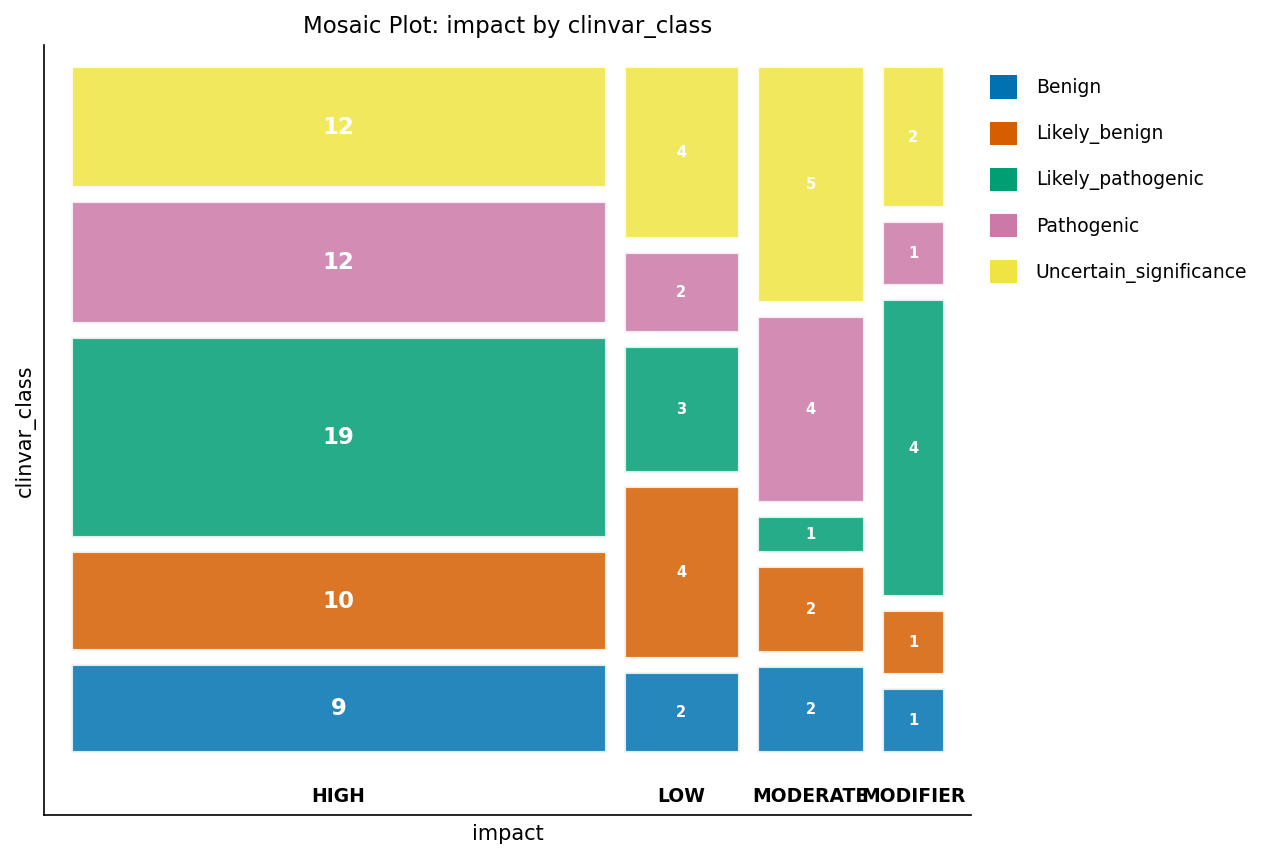

In [4]:
/* --------------------------------------------------------
   Bazowe podsumowanie adnotacji wariantów
   -------------------------------------------------------- */
PROCEDURA CZĘSTOŚCI DANE=variant_annotations;
    TABLES impact * clinvar_class / nocum;
    ETYKIETA impact="Przewidywany poziom efektu"
          clinvar_class="Klasyfikacja ClinVar";
    TYTUŁ "Efekt wariantu wg klasyfikacji ClinVar";
WYKONAJ;

PROCEDURA ŚREDNIE DANE=quality_metrics n mean MIN MAX;
    ZMIENNA mean_coverage ti_tv_ratio contamination_est;
    ETYKIETA mean_coverage="Średnie pokrycie celu"
          ti_tv_ratio="Stosunek tranzycji/transwersji"
          contamination_est="Szacowana kontaminacja";
    TYTUŁ "Podsumowanie metryk jakości sekwencjonowania";
WYKONAJ;

---

                                      Podsumowanie metryk jakości sekwencjonowania                                      

                                      Podsumowanie metryk jakości sekwencjonowania                                      




NOTE: PROC CONTENTS data=variant_annotations

NOTE: PROC CONTENTS: OUT=schema_lengths created with 25 variables
NOTE: PROC CONTENTS: data=variant_annotations obs=100 vars=25 (NOPRINT)
NOTE: DATA schema_lengths


NOTE: Read 25 rows from schema_lengths.
NOTE: Wrote schema_lengths (25 rows, 17 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: PROC SGPLOT data=schema_lengths

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot.svg


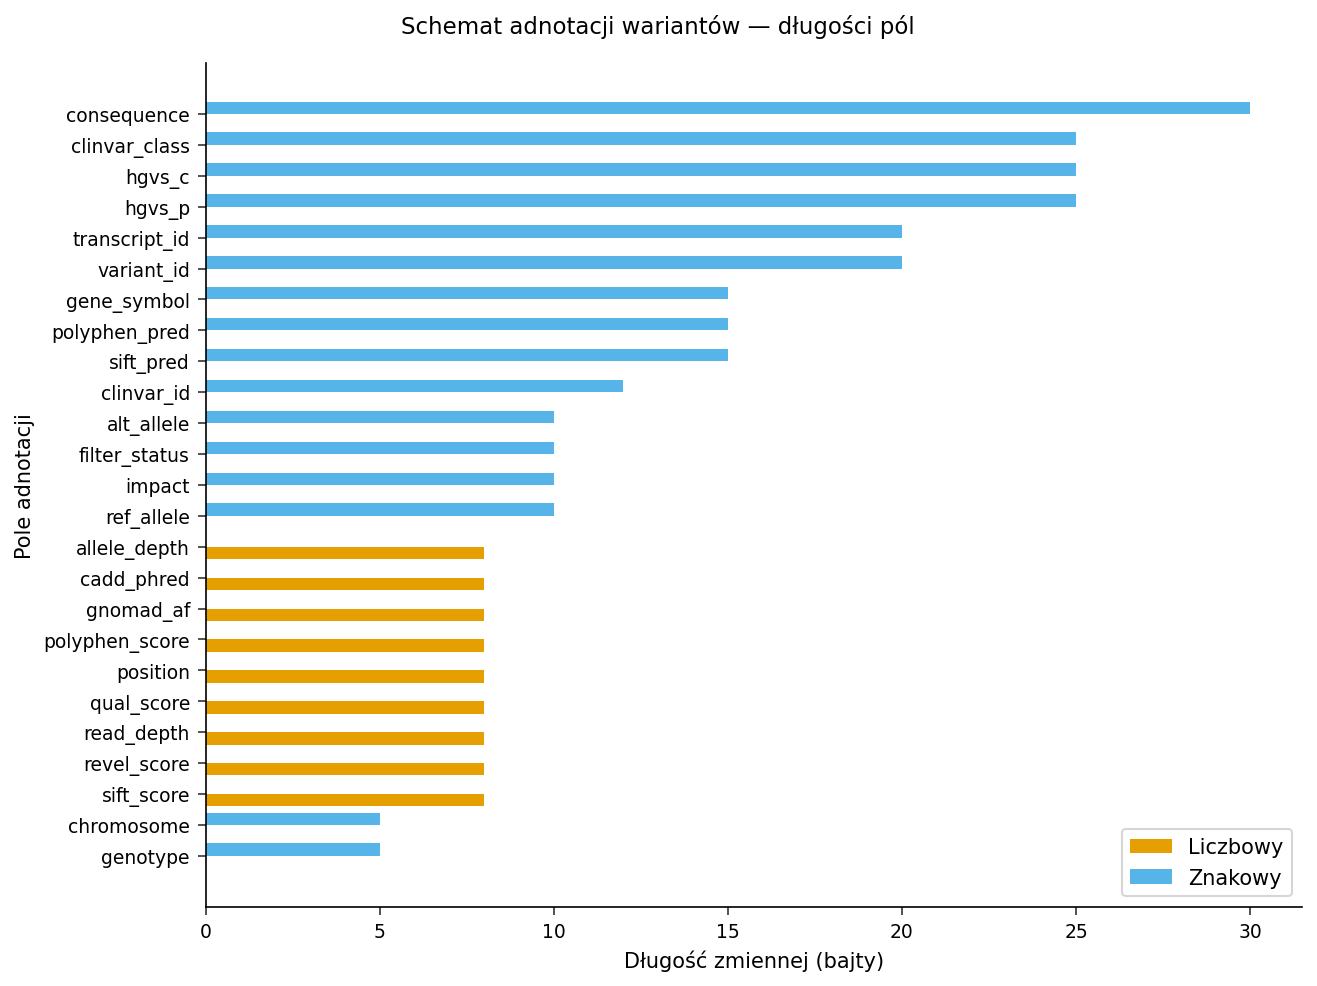

In [5]:
/* --------------------------------------------------------
   Rozkład typu i długości zmiennych.
   Przechwyć metadane schematu adnotacji za pomocą PROC
   CONTENTS OUT=, a następnie wykreśl długości pól według
   typu. Kody TYPE odwzorowują 1 -> Liczbowy, 2 -> Znakowy
   w legendzie.
   -------------------------------------------------------- */
PROCEDURA ZAWARTOŚĆ DANE=variant_annotations out=schema_lengths NOPRINT;
WYKONAJ;

DANE schema_lengths;
    USTAW schema_lengths;
    DŁUGOŚĆ type_label $12;
    JEŚLI TYPE = 1 WTEDY type_label = 'Liczbowy';
    PRZECIWNIE type_label = 'Znakowy';
WYKONAJ;

PROCEDURA SGPLOT DANE=schema_lengths;
    HBAR NAME / RESPONSE=DŁUGOŚĆ GROUP=type_label
        CATEGORYORDER=respdesc;
    XAXIS ETYKIETA='Długość zmiennej (bajty)';
    YAXIS ETYKIETA='Pole adnotacji';
    TYTUŁ 'Schemat adnotacji wariantów — długości pól';
WYKONAJ;

---

In [6]:
/* --------------------------------------------------------
   PROC CONTENTS: udokumentuj pełny schemat adnotacji
   wariantów — typy, długości i etykiety dla wszystkich 25
   pól. Przechwyć metadane zmiennych za pomocą OUT=, aby
   dalsze kroki mogły walidować schemat programowo.
   -------------------------------------------------------- */
PROCEDURA ZAWARTOŚĆ DANE=variant_annotations out=variant_schema NOPRINT;
WYKONAJ;

PROCEDURA DRUKUJ DANE=variant_schema label;
    ZMIENNA NAME TYPE DŁUGOŚĆ VARNUM LABEL;
    label NAME="Nazwa pola" TYPE="Typ" DŁUGOŚĆ="Długość"
          VARNUM="Nr zmiennej" LABEL="Opis";
    TYTUŁ "Zbiór adnotacji wariantów — pełny schemat";
WYKONAJ;

                                      Podsumowanie metryk jakości sekwencjonowania                                      

                                       Zbiór adnotacji wariantów — pełny schemat                                        

  Obs      Nazwa pola  Typ     Długość  Nr zmiennej                                 Opis
    1  allele_depth      1           8           22  Głębokość allelu alternatywnego
    2  alt_allele        2          10            5  Allel alternatywny
    3  cadd_phred        1           8           19  Ocena CADD Phred
    4  chromosome        2           5            2  Chromosom
    5  clinvar_class     2          25           13  Klasyfikacja ClinVar
    6  clinvar_id        2          12           14  Numer akcesyjny ClinVar
    7  consequence       2          30            8  Efekt wg Sequence Ontology
    8  filter_status     2          10           25  Status filtra
    9  gene_symbol       2          15            6  Symbol genu HGNC
   10  ge


NOTE: PROC CONTENTS data=variant_annotations

NOTE: PROC CONTENTS: OUT=variant_schema created with 25 variables
NOTE: PROC CONTENTS: data=variant_annotations obs=100 vars=25 (NOPRINT)
NOTE: PROC PRINT data=variant_schema

NOTE: PROC PRINT completed: 25 observations printed, 5 variables


In [7]:
/* --------------------------------------------------------
   PROC CONTENTS: udokumentuj schemat panelu genów
   -------------------------------------------------------- */
PROCEDURA ZAWARTOŚĆ DANE=gene_panel out=panel_schema NOPRINT;
WYKONAJ;

PROCEDURA DRUKUJ DANE=panel_schema label;
    ZMIENNA NAME TYPE DŁUGOŚĆ VARNUM LABEL;
    label NAME="Nazwa pola" TYPE="Typ" DŁUGOŚĆ="Długość"
          VARNUM="Nr zmiennej" LABEL="Opis";
    TYTUŁ "Definicja panelu genów — schemat";
WYKONAJ;

                                       Zbiór adnotacji wariantów — pełny schemat                                        

                                            Definicja panelu genów — schemat                                            

  Obs           Nazwa pola  Typ     Długość  Nr zmiennej                      Opis
    1  chromosome             2           5            3  Chromosom
    2  disease_association    2          50            7  Powiązana choroba
    3  end_pos                1           8            5  Pozycja końcowa genu
    4  gene_name              2          60            2  Pełna nazwa genu
    5  gene_symbol            2          15            1  Symbol genu HGNC
    6  inheritance            2           5            8  Wzorzec dziedziczenia
    7  panel_name             2          30            6  Kliniczny panel genów
    8  start_pos              1           8            4  Pozycja początkowa genu




NOTE: PROC CONTENTS data=gene_panel

NOTE: PROC CONTENTS: OUT=panel_schema created with 8 variables
NOTE: PROC CONTENTS: data=gene_panel obs=15 vars=8 (NOPRINT)
NOTE: PROC PRINT data=panel_schema

NOTE: PROC PRINT completed: 8 observations printed, 5 variables


In [8]:
/* --------------------------------------------------------
   PROC CONTENTS: udokumentuj schemat metryk kontroli jakości
   -------------------------------------------------------- */
PROCEDURA ZAWARTOŚĆ DANE=quality_metrics out=qc_schema NOPRINT;
WYKONAJ;

PROCEDURA DRUKUJ DANE=qc_schema label;
    ZMIENNA NAME TYPE DŁUGOŚĆ VARNUM LABEL;
    label NAME="Nazwa pola" TYPE="Typ" DŁUGOŚĆ="Długość"
          VARNUM="Nr zmiennej" LABEL="Opis";
    TYTUŁ "Metryki jakości sekwencjonowania — schemat";
WYKONAJ;

                                            Definicja panelu genów — schemat                                            

                                       Metryki jakości sekwencjonowania — schemat                                       

  Obs         Nazwa pola  Typ     Długość  Nr zmiennej                                    Opis
    1  contamination_est    1           8           10  Szacowana kontaminacja
    2  het_hom_ratio        1           8            9  Stosunek Het/Hom
    3  mean_coverage        1           8            4  Średnie pokrycie celu
    4  pct_target_100x      1           8            6  Procent zasad >= 100x
    5  pct_target_20x       1           8            5  Procent zasad >= 20x
    6  platform             2          15            3  Platforma sekwencjonowania
    7  qc_status            2          10           11  Status kontroli jakości
    8  run_id               2          12            2  ID uruchomienia sekwencjonowania
    9  sample_id        


NOTE: PROC CONTENTS data=quality_metrics

NOTE: PROC CONTENTS: OUT=qc_schema created with 11 variables
NOTE: PROC CONTENTS: data=quality_metrics obs=50 vars=11 (NOPRINT)
NOTE: PROC PRINT data=qc_schema

NOTE: PROC PRINT completed: 11 observations printed, 5 variables


In [9]:
/* --------------------------------------------------------
   Walidacja schematu: sprawdź, czy pola adnotacji spełniają
   wymagania potoku interpretacji ACMG. Odczytuje metadane
   PROC CONTENTS OUT=, gdzie TYPE=1 oznacza typ liczbowy,
   a TYPE=2 typ znakowy.
   -------------------------------------------------------- */
DANE schema_validation;
    USTAW variant_schema;
    DŁUGOŚĆ requirement $60 status $14;
    /* Numeryczne pola ocen muszą być typu liczbowego (TYPE=1) */
    JEŚLI NAME IN ('gnomad_af' 'sift_score' 'polyphen_score'
        'cadd_phred' 'revel_score' 'qual_score'
        'allele_depth' 'read_depth' 'position')
        AND TYPE ne 1 WTEDY POWTÓRZ;
        requirement = 'Musi być numeryczne dla progów ocen';
        status = 'NIEZALICZONO';
    KONIEC;
    PRZECIWNIE JEŚLI NAME IN ('gnomad_af' 'sift_score' 'polyphen_score'
        'cadd_phred' 'revel_score' 'qual_score'
        'allele_depth' 'read_depth' 'position')
        AND TYPE = 1 WTEDY POWTÓRZ;
        requirement = 'Potwierdzono typ numeryczny';
        status = 'ZALICZONO';
    KONIEC;
    /* Klasa ClinVar wymaga wystarczającej długości znakowej */
    PRZECIWNIE JEŚLI NAME = 'clinvar_class' AND DŁUGOŚĆ < 25 WTEDY POWTÓRZ;
        requirement = 'Min. $25 dla pełnego tekstu klasyfikacji';
        status = 'NIEZALICZONO';
    KONIEC;
    PRZECIWNIE JEŚLI NAME = 'clinvar_class' WTEDY POWTÓRZ;
        requirement = 'Wystarczająca długość znakowa';
        status = 'ZALICZONO';
    KONIEC;
    /* Każde pole musi mieć etykietę na potrzeby słownika danych */
    PRZECIWNIE JEŚLI LABEL = '' WTEDY POWTÓRZ;
        requirement = 'Wymagana etykieta dla słownika danych';
        status = 'NIEZALICZONO';
    KONIEC;
    PRZECIWNIE POWTÓRZ;
        requirement = 'Walidacja ogólna';
        status = 'ZALICZONO';
    KONIEC;
WYKONAJ;

PROCEDURA DRUKUJ DANE=schema_validation label;
    ZMIENNA NAME TYPE DŁUGOŚĆ LABEL requirement status;
    label NAME="Nazwa pola" TYPE="Typ" DŁUGOŚĆ="Długość"
          LABEL="Opis" requirement="Wymaganie" status="Status";
    TYTUŁ "Raport walidacji schematu potoku ACMG";
WYKONAJ;

                                         Raport walidacji schematu potoku ACMG                                          

  Obs      Nazwa pola  Typ     Długość                                 Opis                          Wymaganie     Status
    1  allele_depth      1           8  Głębokość allelu alternatywnego      Potwierdzono typ numeryczny        ZALICZONO
    2  alt_allele        2          10  Allel alternatywny                   Walidacja ogólna                   ZALICZONO
    3  cadd_phred        1           8  Ocena CADD Phred                     Potwierdzono typ numeryczny        ZALICZONO
    4  chromosome        2           5  Chromosom                            Walidacja ogólna                   ZALICZONO
    5  clinvar_class     2          25  Klasyfikacja ClinVar                 Wystarczająca długość znakowa      ZALICZONO
    6  clinvar_id        2          12  Numer akcesyjny ClinVar              Walidacja ogólna                   ZALICZONO
    7  consequence      


NOTE: DATA schema_validation


NOTE: Read 25 rows from variant_schema.
NOTE: Wrote schema_validation (25 rows, 18 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: PROC PRINT data=schema_validation

NOTE: PROC PRINT completed: 25 observations printed, 6 variables


---

### Interpretacja

Schemat adnotacji wariantów zawiera 25 pól obejmujących współrzędne genomowe, przewidywania funkcjonalne, częstości populacyjne oraz wskaźniki jakości dla poszczególnych próbek. Wszystkie dziewięć numerycznych pól ocen (częstość allelu gnomAD, SIFT, PolyPhen-2, CADD, REVEL, ocena jakości, głębokość allelu, głębokość odczytu oraz pozycja genomowa) ma poprawnie przypisany typ numeryczny, co umożliwia silnikowi interpretacji ACMG stosowanie filtrowania opartego na progach bez konwersji typów. Pole clinvar_class o długości $25 mieści najdłuższy łańcuch klasyfikacji ClinVar (Uncertain_significance o długości 24 znaków). Każde pole adnotacji jest opatrzone opisową etykietą, co spełnia wymóg słownika danych laboratorium klinicznego wynikający z wymagań akredytacyjnych CAP. Schemat panelu genów odwzorowuje 15 genów predyspozycji nowotworowej wraz z wzorcami dziedziczenia i powiązaniami chorobowymi, stanowiąc ramy referencyjne dla adnotacji wariant–gen. Zbiór danych metryk kontroli jakości sekwencjonowania dokumentuje 50 próbek w 5 uruchomieniach, wraz z szacunkami kontaminacji i progami pokrycia, które warunkują wiarygodność wywoływania wariantów. Ten pakiet dokumentacji schematu wspiera dossier walidacyjne laboratorium dla zgłoszenia do programu CLEP stanu Nowy Jork.

---

In [10]:
/* --------------------------------------------------------
   Eksport dokumentacji schematu wariantów oraz raportu
   walidacji na potrzeby akredytacji laboratorium
   -------------------------------------------------------- */
PROCEDURA EKSPORTUJ DANE=variant_schema
    OUTFILE='variant_annotation_schema.csv'
    DBMS=csv REPLACE;
WYKONAJ;

PROCEDURA EKSPORTUJ DANE=schema_validation
    OUTFILE='acmg_schema_validation.csv'
    DBMS=csv REPLACE;
WYKONAJ;


NOTE: PROC EXPORT data=variant_schema outfile=variant_annotation_schema.csv

NOTE: Exported 25 rows to variant_annotation_schema.csv.
NOTE: PROC EXPORT data=schema_validation outfile=acmg_schema_validation.csv

NOTE: Exported 25 rows to acmg_schema_validation.csv.


---
<div style="border-top: 1px solid #e0e0e0; padding-top: 16px; margin-top: 20px; display: flex; justify-content: space-between; align-items: center;">
<div style="font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #9e9e9e; font-size: 12px;">
&copy; 2026 Jenner Analytics Ltd &nbsp;&bull;&nbsp; Poufne
</div>
<div style="font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #9e9e9e; font-size: 12px;">
Napędzane przez <a href="https://docs.jenneranalytics.com" style="color: #e8a435; text-decoration: none;">Jenner</a>
</div>
</div>